In [1]:
# Import Libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [3]:
#  Load dataset
df = pd.read_csv('../data/raw/exoplanet_data.csv', comment= '#')

In [4]:

df.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,AU Mic b,AU Mic,1,1,4,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2024-09-28,2023-12,2024-09-28
1,AU Mic c,AU Mic,1,1,4,Transit,2021.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2024-09-28,2023-12,2024-09-28
2,BD+05 4868 A b,BD+05 4868 A,1,2,1,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.010,7.448,0.026,-0.026,9.84152,0.000476,-0.000476,2025-03-21,2025-01,2025-03-21
3,BD-14 3065 b,BD-14 3065 A,1,3,1,Transit,2024.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.013,9.932,0.026,-0.026,10.91000,0.001617,-0.001617,2024-06-25,2024-03,2024-06-25
4,DS Tuc A b,DS Tuc A,1,2,1,Transit,2019.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.030,6.676,0.034,-0.034,8.31926,0.001025,-0.001025,2019-07-03,2019-07,2019-07-11


In [5]:
df.shape

(746, 92)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746 entries, 0 to 745
Data columns (total 92 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          746 non-null    object 
 1   hostname         746 non-null    object 
 2   default_flag     746 non-null    int64  
 3   sy_snum          746 non-null    int64  
 4   sy_pnum          746 non-null    int64  
 5   discoverymethod  746 non-null    object 
 6   disc_year        745 non-null    float64
 7   disc_facility    746 non-null    object 
 8   soltype          746 non-null    object 
 9   pl_controv_flag  746 non-null    int64  
 10  pl_refname       746 non-null    object 
 11  pl_orbper        743 non-null    float64
 12  pl_orbpererr1    723 non-null    float64
 13  pl_orbpererr2    723 non-null    float64
 14  pl_orbperlim     743 non-null    float64
 15  pl_orbsmax       652 non-null    float64
 16  pl_orbsmaxerr1   639 non-null    float64
 17  pl_orbsmaxerr2  

In [7]:
df.describe()

,default_flag,sy_snum,sy_pnum,disc_year,pl_controv_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
count,746.0,746.000000,746.000000,745.000000,746.000000,743.000000,7.230000e+02,7.230000e+02,743.0,652.000000,...,741.000000,741.000000,741.000000,741.000000,744.000000,742.000000,742.000000,744.000000,744.000000,744.000000
mean,1.0,1.121984,1.631367,2022.777181,0.004021,13.874506,1.965765e-03,-1.787445e-03,0.0,0.090386,...,-1.611606,11.524677,0.053822,-0.053822,9.039074,0.035345,-0.035345,11.131019,0.000500,-0.000500
std,0.0,0.355020,1.069169,1.783667,0.063330,30.385708,2.664913e-02,2.449135e-02,0.0,0.105419,...,3.255803,2.087233,0.102442,0.102442,1.502603,0.366202,0.366202,1.847145,0.000422,0.000422
min,1.0,1.000000,1.000000,2018.000000,0.000000,0.238182,2.800000e-08,-5.800000e-01,0.0,0.006220,...,-32.536000,5.650000,0.002000,-1.133000,4.241000,0.011000,-9.995000,5.512800,0.000112,-0.004236
25%,1.0,1.000000,1.000000,2022.000000,0.000000,3.316956,4.000000e-06,-6.000000e-05,0.0,0.038325,...,-1.568000,9.969000,0.012000,-0.057000,8.054250,0.019000,-0.023000,9.776800,0.000263,-0.000586
50%,1.0,1.000000,1.000000,2023.000000,0.000000,5.799816,1.300000e-05,-1.335500e-05,0.0,0.060000,...,-0.360100,11.446000,0.030000,-0.030000,9.045500,0.021000,-0.021000,11.176100,0.000396,-0.000396
75%,1.0,1.000000,2.000000,2024.000000,0.000000,12.832443,6.000000e-05,-3.900000e-06,0.0,0.102175,...,-0.100400,12.603000,0.057000,-0.012000,10.171250,0.023000,-0.019000,12.218975,0.000586,-0.000263
max,1.0,3.000000,6.000000,2026.000000,1.000000,482.819100,5.900000e-01,-8.700000e-08,0.0,1.152000,...,-0.002835,18.000000,1.133000,-0.002000,15.548000,9.995000,-0.011000,16.958000,0.004236,-0.000112


In [8]:
# Missing value
df.isnull().sum()

# duplicates identify

df.drop_duplicates(inplace=True)
df.dropna(how='all', inplace=True)

print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


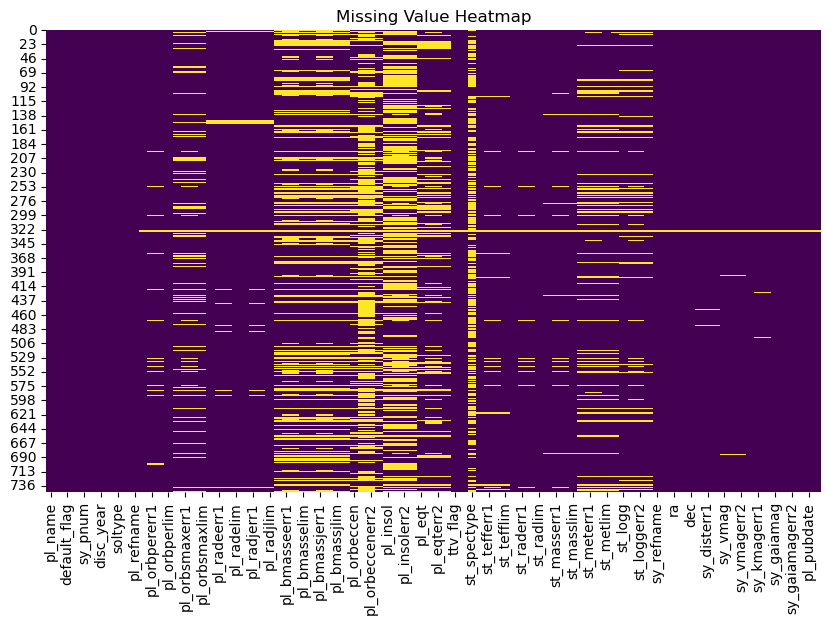

In [9]:
# Heatmap for Missing Values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

In [10]:
# Selecting features columns for habitability analysis

selected_cols = ['pl_name', 'pl_rade','pl_bmasse', 'pl_orbper','pl_orbsmax','pl_eqt','st_teff','st_rad','st_mass','st_met','st_spectype']

if 'pl_dens' in df.columns: selected_cols.append('pl_dens')
if 'st_lum' in df.columns: selected_cols.append('st_lum')

df_m1= df[selected_cols].copy()

df_m1.shape


(746, 11)

In [11]:
# Data Quality: Duplicates & Completely missing rows

df_m1.drop_duplicates(inplace=True)
df_m1.dropna(how='all', inplace=True)

In [12]:
# 3. Handling Missing Data 
num_cols = ['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_eqt', 'st_teff', 'st_rad', 'st_mass', 'st_met',]
df_m1[num_cols] = df_m1[num_cols].apply(lambda x: x.fillna(x.median()))
df_m1['st_spectype'] = df_m1['st_spectype'].fillna(df_m1['st_spectype'].mode()[0])

In [13]:
df_m1['st_spectype'] = df_m1['st_spectype'].astype(str).str[0]

# One-Hot Encoding: Yeh 'st_spectype' ko numeric columns (0 aur 1) mein badal dega
df_m1 = pd.get_dummies(df_m1, columns=['st_spectype'], prefix='spec', drop_first=True)

In [14]:
df_m1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746 entries, 0 to 745
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pl_name     746 non-null    object 
 1   pl_rade     746 non-null    float64
 2   pl_bmasse   746 non-null    float64
 3   pl_orbper   746 non-null    float64
 4   pl_orbsmax  746 non-null    float64
 5   pl_eqt      746 non-null    float64
 6   st_teff     746 non-null    float64
 7   st_rad      746 non-null    float64
 8   st_mass     746 non-null    float64
 9   st_met      746 non-null    float64
 10  spec_F      746 non-null    bool   
 11  spec_G      746 non-null    bool   
 12  spec_K      746 non-null    bool   
 13  spec_M      746 non-null    bool   
 14  spec_m      746 non-null    bool   
dtypes: bool(5), float64(9), object(1)
memory usage: 62.1+ KB


In [15]:
# 4. UNIT STANDARDIZATION (Ensuring Earth=1 and Sun=1)
if 'pl_bmassj' in df_m1.columns:
    df_m1['pl_bmasse'] = df_m1['pl_bmassj'] * 317.8
if 'pl_radj' in df_m1.columns:
    df_m1['pl_rade'] = df_m1['pl_radj'] * 11.21

In [16]:
# Remove physically impossible values

df_m1 = df_m1[
    (df_m1["pl_rade"] > 0) & 
    (df_m1["pl_bmasse"] > 0) & 
    (df_m1["pl_orbper"] > 0) & 
    (df_m1["pl_orbsmax"] > 0) & 
    (df_m1["pl_eqt"] > 0) & 
    (df_m1["st_teff"] > 0) & 
    (df_m1["st_rad"] > 0) & 
    (df_m1["st_mass"] > 0)
]

In [17]:
# 5. IQR Method for Outliers (Only for specific features)
print("IQR Before shape:", df_m1.shape)
for col in ['pl_orbper', 'st_teff', 'pl_rade']:
    Q1 = df_m1[col].quantile(0.25)
    Q3 = df_m1[col].quantile(0.75)
    IQR = Q3 - Q1
    df_m1 = df_m1[(df_m1[col] >= Q1 - 1.5 * IQR) & (df_m1[col] <= Q3 + 1.5 * IQR)]
print("IQR final shape:", df_m1.shape)

IQR Before shape: (746, 15)
IQR final shape: (672, 15)


In [18]:
# MISSING VALUES FIX
numeric_cols = ['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_eqt', 'st_teff', 'st_mass']
df_m1[numeric_cols] = df_m1[numeric_cols].fillna(df_m1[numeric_cols].median())
df_m1 = df_m1[(df_m1[num_cols] > 0).all(axis=1)]

habitable
0    450
Name: count, dtype: int64


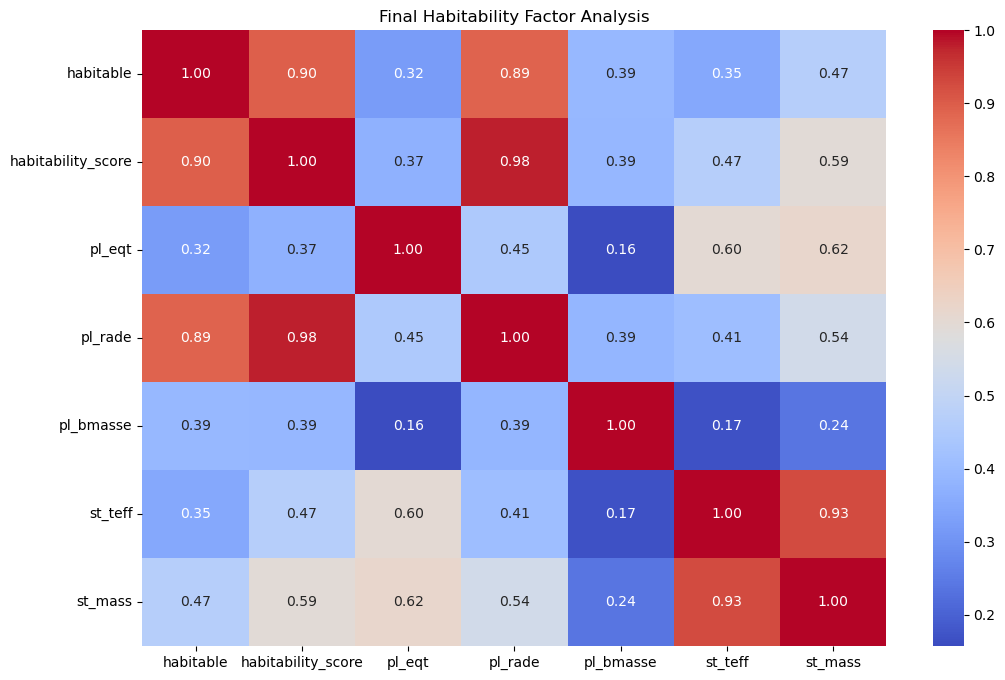

Final DataFrame Shape: (450, 26)


In [20]:
#FEATURE ENGINEERING

df_m1["st_lum"] = (df_m1["st_rad"]**2) * ((df_m1["st_teff"]/5778)**4)

# A. HABITABILITY SCORE INDEX 
# Temperature score (best near Earth ~288K, habitable range wide)
df_m1["temp_score"] = (1 - abs(df_m1["pl_eqt"] - 288) / 120).clip(0, 1)

# Radius score (Earth ≈ 1 Earth radius)
df_m1["radius_score"] = (1 - abs(df_m1["pl_rade"] - 1) / 2).clip(0, 1)

# Distance score (Earth ≈ 1 AU)
df_m1["dist_score"] = (1 - abs(df_m1["pl_orbsmax"] - 1) / 1.5).clip(0, 1)

# Stellar luminosity score (Earth-like stars best near 1)
df_m1["lum_score"] = (1 - abs(df_m1["st_lum"] - 1) / 2).clip(0, 1)

# FINAL HABITABILITY SCORE (weighted)
df_m1["habitability_score"] = (
    0.4 * df_m1["temp_score"] +
    0.2 * df_m1["radius_score"] +
    0.2 * df_m1["dist_score"] +
    0.2 * df_m1["lum_score"]
)

# Binary target
df_m1["habitable"] = (df_m1["habitability_score"] > 0.55).astype(int)

print(df_m1["habitable"].value_counts())

# B. STELLAR COMPATIBILITY INDEX 
df_m1["stellar_temp_score"] = 1 - abs(df_m1["st_teff"] - 5778) / df_m1["st_teff"].max()
df_m1["stellar_mass_score"] = 1 - abs(df_m1["st_mass"] - 1) / df_m1["st_mass"].max()
df_m1["stellar_compatibility_index"] = (df_m1["stellar_temp_score"].clip(0,1) + df_m1["stellar_mass_score"].clip(0,1)) / 2

# C. ORBITAL STABILITY FACTOR 
# Using Orbital period and Semi-major axis 
df_m1["orbital_stability"] = (1 - abs(df_m1["pl_orbsmax"] - 1)).clip(0, 1) * (1 - abs(df_m1["pl_orbper"] - 365) / 365).clip(0, 1)


# D. TARGET VARIABLE CREATION (Binary Class)
df_m1['habitable'] = (df_m1['habitability_score'] > 0.3).astype(int)

# FEATURE SCALING 
scaler = MinMaxScaler()
scale_features = ['pl_eqt', 'pl_rade', 'pl_bmasse', 'st_teff', 'habitability_score']
df_m1[scale_features] = scaler.fit_transform(df_m1[scale_features])

# VISUALIZATION (HEATMAP) 
plt.figure(figsize=(12, 8))
heatmap_cols = ['habitable', 'habitability_score', 'pl_eqt', 'pl_rade', 'pl_bmasse', 'st_teff', 'st_mass']
sns.heatmap(df_m1[heatmap_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Final Habitability Factor Analysis")
plt.show()
print(f"Final DataFrame Shape: {df_m1.shape}")




In [21]:
print(df_m1.columns)

Index(['pl_name', 'pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_eqt',
       'st_teff', 'st_rad', 'st_mass', 'st_met', 'spec_F', 'spec_G', 'spec_K',
       'spec_M', 'spec_m', 'st_lum', 'temp_score', 'radius_score',
       'dist_score', 'lum_score', 'habitability_score', 'habitable',
       'stellar_temp_score', 'stellar_mass_score',
       'stellar_compatibility_index', 'orbital_stability'],
      dtype='object')


In [22]:
print(df_m1["habitable"].value_counts())

habitable
0    251
1    199
Name: count, dtype: int64


In [23]:
save_dir = '../data/processed'
os.makedirs(save_dir, exist_ok=True) 

# 2. File Save karein
save_path = os.path.join(save_dir, 'preprocessed.csv')
df_m1.to_csv(save_path, index=False)